In [1]:
import sys
!{sys.executable} -m pip install git+https://github.com/amazon-science/chronos-forecasting.git

  Cloning https://github.com/amazon-science/chronos-forecasting.git to c:\users\123\appdata\local\temp\pip-req-build-n_aqxiyz
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 32111085d85de6cc17d0ea4dd08adba324f57590
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git 'C:\Users\123\AppData\Local\Temp\pip-req-build-n_aqxiyz'

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: C:\Users\123\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

from chronos import ChronosPipeline

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

C:\Users\123\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0+cpu
CUDA available: False


In [3]:
url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(353500, 3)


,item_id,timestamp,target
0,H1,1750-01-01 00:00:00,605.0
1,H1,1750-01-01 01:00:00,586.0
2,H1,1750-01-01 02:00:00,586.0
3,H1,1750-01-01 03:00:00,559.0
4,H1,1750-01-01 04:00:00,511.0


In [4]:
series_id = 'H1'
series_data = df[df['item_id'] == series_id]['target'].values

print(f"\nРяд '{series_id}': {len(series_data)} наблюдений")
print(f"Первые 10 значений: {series_data[:10]}")
print(f"Статистика: min={series_data.min():.1f}, max={series_data.max():.1f}, mean={series_data.mean():.1f}")


Ряд 'H1': 700 наблюдений
Первые 10 значений: [605. 586. 586. 559. 511. 443. 422. 395. 382. 370.]
Статистика: min=349.0, max=926.0, mean=638.5


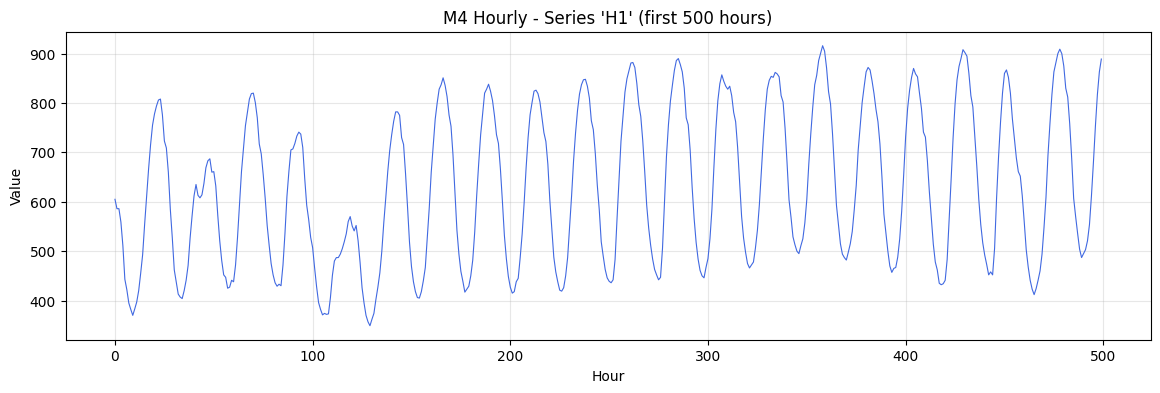

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(series_data[:500], color='royalblue', linewidth=0.8)  # Покажем первые 500 точек
plt.title(f"M4 Hourly - Series '{series_id}' (first 500 hours)")
plt.xlabel("Hour")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.show()

In [6]:
print("Загрузка Chronos-t5-small...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.float32,
)
print("Готово!")

Загрузка Chronos-t5-small...


`torch_dtype` is deprecated! Use `dtype` instead!


Готово!


In [12]:
context_length = 24 * 28
prediction_length = 24 * 7

total_length = len(series_data)
print(f"Total series length: {total_length} hours ({total_length/24:.0f} days)")

required_length = context_length + prediction_length
if total_length < required_length:
    print(f"Warning! Need {required_length} hours, but have {total_length}")
    context_length = total_length - prediction_length
    print(f"Reducing context_length to {context_length} hours ({context_length/24:.0f} days)")

context = torch.tensor(series_data[-context_length - prediction_length:-prediction_length], dtype=torch.float32)
actual = series_data[-prediction_length:]

print(f"\nContext: {len(context)} hours ({len(context)/24:.0f} days)")
print(f"Forecast: {prediction_length} hours ({prediction_length/24:.0f} days)")
print(f"Actual for test: {len(actual)} hours")

Total series length: 700 hours (29 days)
Warning! Need 840 hours, but have 700
Reducing context_length to 532 hours (22 days)

Context: 532 hours (22 days)
Forecast: 168 hours (7 days)
Actual for test: 168 hours


In [13]:
forecast = pipeline.predict(
    context,
    prediction_length=prediction_length,
    num_samples=20,
    temperature=1.0,
    top_k=50,
    top_p=0.95,
)

forecast_np = forecast.numpy()
print(f"forecast_np shape: {forecast_np.shape}")

if forecast_np.ndim == 3 and forecast_np.shape[0] == 1:
    forecast_np = forecast_np[0]
    print(f"After squeeze: {forecast_np.shape}")

quantiles = np.quantile(forecast_np, [0.1, 0.5, 0.9], axis=0)

median_forecast = quantiles[1]
lower_bound = quantiles[0]
upper_bound = quantiles[2]

print(f"median_forecast shape: {median_forecast.shape}")
print(f"actual shape: {actual.shape}")

We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 


forecast_np shape: (1, 20, 168)
After squeeze: (20, 168)
median_forecast shape: (168,)
actual shape: (168,)


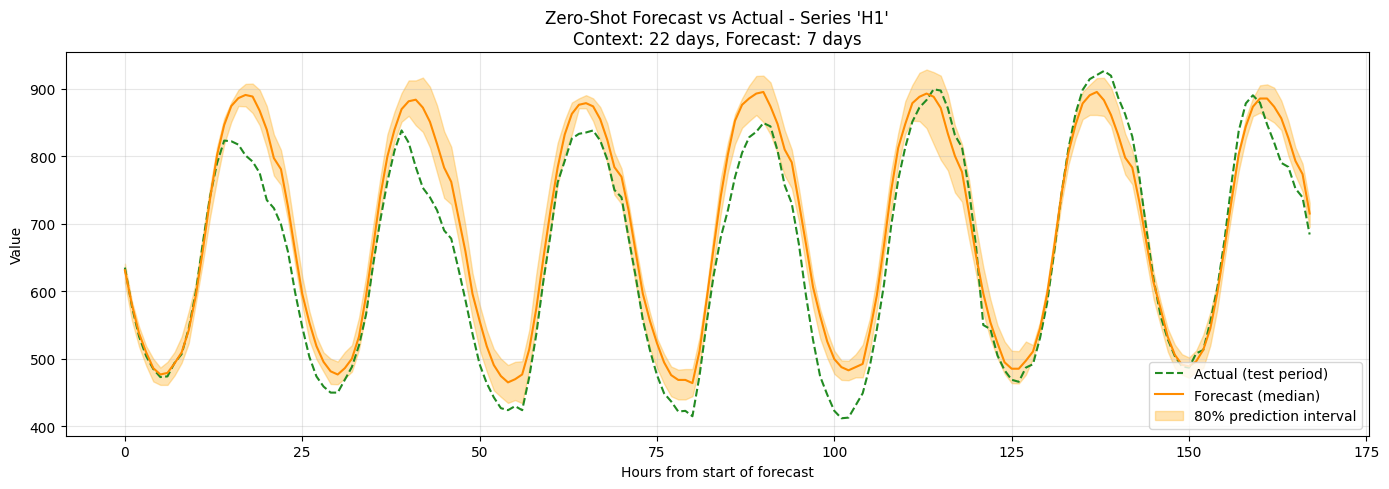

In [14]:
time_hours = np.arange(prediction_length)

plt.figure(figsize=(14, 5))

plt.plot(time_hours, actual, label="Actual (test period)", 
         color="forestgreen", linewidth=1.5, linestyle="--")

plt.plot(time_hours, median_forecast, label="Forecast (median)", 
         color="darkorange", linewidth=1.5)

plt.fill_between(time_hours, lower_bound, upper_bound, 
                 color="orange", alpha=0.3, label="80% prediction interval")

plt.title(f"Zero-Shot Forecast vs Actual - Series '{series_id}'\nContext: {len(context)//24} days, Forecast: {prediction_length//24} days")
plt.xlabel("Hours from start of forecast")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("zero_shot_forecast_m4.png", dpi=150)
plt.show()

In [ ]:
def weighted_quantile_loss(actual, forecast_samples, quantile_levels=[0.1, 0.5, 0.9]):
    losses = []
    for q_level in quantile_levels:
        pred_q = np.quantile(forecast_samples, q_level, axis=0)
        errors = actual - pred_q
        weight = 2.0 * q_level if q_level < 0.5 else 2.0 * (1.0 - q_level) if q_level > 0.5 else 1.0
        losses.append(np.mean(weight * np.abs(errors)))
    return np.mean(losses)

print(f"forecast_np shape for WQL: {forecast_np.shape}")

mae = mean_absolute_error(actual, median_forecast)
smape = 100 * np.mean(2 * np.abs(actual - median_forecast) / (np.abs(actual) + np.abs(median_forecast)))
wql = weighted_quantile_loss(actual, forecast_np)


print(f"MAE:  {mae:.3f}")
print(f"sMAPE: {smape:.2f}%")
print(f"WQL:  {wql:.4f}")
print("=" * 50)

results_df = pd.DataFrame([{
    "model": "chronos-t5-small-zero-shot",
    "series": series_id,
    "context_length": context_length,
    "prediction_length": prediction_length,
    "MAE": mae,
    "sMAPE": smape,
    "WQL": wql
}])
results_df.to_csv("zero_shot_results_m4.csv", index=False)
print("\nResults saved to zero_shot_results_m4.csv")

forecast_np shape for WQL: (20, 168)
Zero-Shot Results - Chronos-t5-small on M4 Hourly
MAE:  39.171
sMAPE: 5.98%
WQL:  18.6851

Results saved to zero_shot_results_m4.csv
